# Classical Derivative Pricing: Black-Scholes-Merton Model
The Black-Scholes model provides an exact, analytical solution for the price of a European Call option. 
We will use this exact mathematical expectation as the **benchmark** to evaluate the accuracy of our Monte Carlo and Quantum Amplitude Estimation models.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, lognorm

# --- Financial Parameters ---
S0 = 100.0            # Initial spot price
K = 110.0             # Strike price
volatility = 0.4      # Annualized volatility
risk_free_rate = 0.05 # Annual risk-free interest rate
maturity = 0.1        # Time to maturity in years

def black_scholes_call(S, K, T, r, sigma):
    """Calculates the discounted Black-Scholes price of a European Call."""
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

bs_price = black_scholes_call(S0, K, maturity, risk_free_rate, volatility)
expected_payoff = bs_price * np.exp(risk_free_rate * maturity)

print("=== BLACK-SCHOLES EXACT PRICING ===")
print(f"Discounted Option Price:  ${bs_price:.4f}")
print(f"Expected Payoff at Expiry: ${expected_payoff:.4f}  <-- Benchmark for Quantum")

=== BLACK-SCHOLES EXACT PRICING ===
Discounted Option Price:  $1.8444
Expected Payoff at Expiry: $1.8536  <-- Benchmark for Quantum


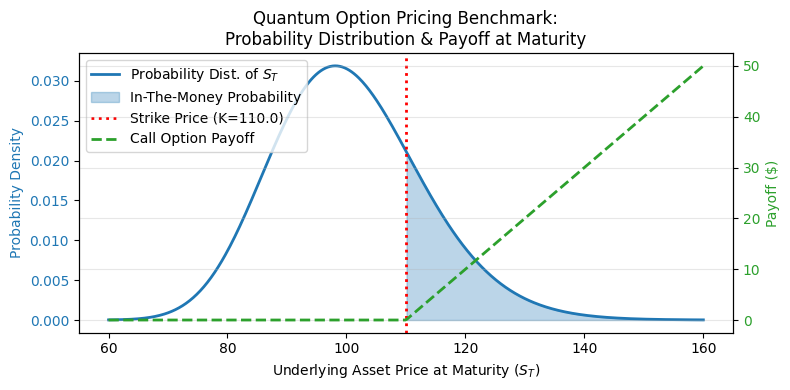

In [5]:
# --- Visualization ---

# Define a range for the underlying asset price at maturity (S_T)
S_range = np.linspace(60, 160, 500)

# Calculate the Payoff at Maturity: max(S_T - K, 0)
payoff = np.maximum(S_range - K, 0)

# Calculate Lognormal Probability Density Function (PDF) for S_T
# (This is the distribution the Quantum Circuit loads into the qubits)
mu = np.log(S0) + (risk_free_rate - 0.5 * volatility**2) * maturity
sigma_T = volatility * np.sqrt(maturity)
pdf = lognorm.pdf(S_range, s=sigma_T, scale=np.exp(mu))

# Create the plot
fig, ax1 = plt.subplots(figsize=(8, 4))

# Plot 1: Probability Distribution (Left Y-Axis)
color1 = 'tab:blue'
ax1.set_xlabel('Underlying Asset Price at Maturity ($S_T$)')
ax1.set_ylabel('Probability Density', color=color1)
ax1.plot(S_range, pdf, color=color1, linewidth=2, label='Probability Dist. of $S_T$')
ax1.tick_params(axis='y', labelcolor=color1)

# Shade the "In-The-Money" probability area
itm_S = S_range[S_range >= K]
itm_pdf = pdf[S_range >= K]
ax1.fill_between(itm_S, itm_pdf, alpha=0.3, color=color1, label='In-The-Money Probability')

# Plot 2: Option Payoff (Right Y-Axis)
ax2 = ax1.twinx()  
color2 = 'tab:green'
ax2.set_ylabel('Payoff ($)', color=color2)
ax2.plot(S_range, payoff, color=color2, linewidth=2, linestyle='--', label='Call Option Payoff')
ax2.tick_params(axis='y', labelcolor=color2)

# Mark the Strike Price
ax1.axvline(K, color='red', linestyle=':', linewidth=2, label=f'Strike Price (K={K})')

# Formatting and Legends
plt.title('Quantum Option Pricing Benchmark:\nProbability Distribution & Payoff at Maturity')
fig.tight_layout()

# Combine legends from both axes
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

plt.grid(alpha=0.3)
plt.show()